### SGCRL implementation - Four Rooms GridWorld - Discrete Action Space


In [1]:
import sys
sys.path.insert(0, "/Users/juntan/Documents/MSc_Applied_Machine_Learning/Repos/Dissertation/MSc_Dissertation/src")

from environments.fourrooms_discrete import FourRoomsGridWorld, FourRoomsGoalWrapper
from networks import StateActionRepresentationModel, GoalRepresentationModel
from agents import DiscreteGoalConditionedActor
from utils import TrajectoryReplayBufferDiscrete, ReplayBatch
from loss_functions import contrastive_loss
from visualisations import plot_q_diagnostics, plot_policy_rollouts
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim  
import torch.nn.functional as F   
import gymnasium as gym
import copy


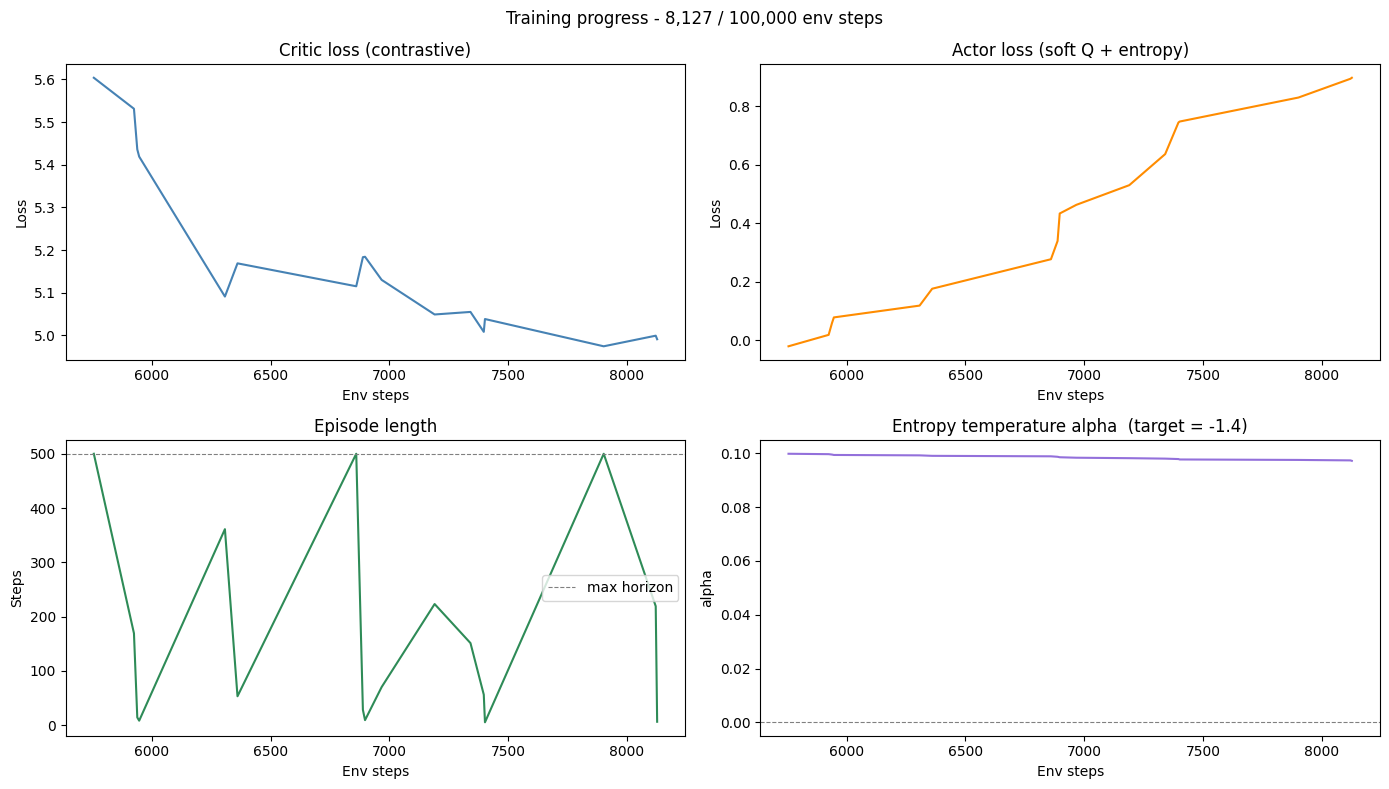

Training complete!
Total env steps: 100,416 | Online gradient updates: 3,802
Replay buffer size: 100,000
Final alpha: 0.041714 | Final mean entropy: 0.0005


In [2]:
# ── Imports for live visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
from IPython.display import clear_output

# ── Hyperparameters ────────────────────────────────────────────────────────────
TOTAL_ENV_STEPS    = 100000   # total environment steps to collect
WARMUP_STEPS       = 5000    # random-action steps before any policy learning
BATCH_SIZE         = 256      # critic / actor batch size
SAMPLES_PER_INSERT = 64       # paper setting: each inserted transition is reused this many times on average
LR                 = 3e-4     # learning rate for critic + actor
INIT_ALPHA         = 0.1      # initial entropy temperature α before automatic tuning
ALPHA_LR           = 3e-4     # learning rate for entropy-temperature (α) tuning
POLYAK_TAU         = 0.005    # τ for Polyak (EMA) target-network update (SAC default)
SLIP_PROB          = 0.00     # transition stochasticity for exploration / coverage
LOG_INTERVAL       = 50       # refresh / print every this many gradient-update steps
MAX_HORIZON        = 500
TARGET_ENTROPY = -np.log(4) 
NUMBER_OF_SGD_UPDATES_PER_STEP = 20
BUFFER_CAPACITY    = 100000
MAX_TRAJECORY_TO_PLOT = 2000
DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"

s_star = torch.tensor([9.0, 9.0], device=DEVICE, dtype=torch.float32)
s_star_batch = s_star.unsqueeze(0)
grad_step = 0
# Discrete setting helper

def onehot_encode_action(action, num_actions=4):
    return F.one_hot(action.long(), num_classes=num_actions).float()

def compute_valid_action_mask_batch(obs_batch, env_core, device):
    obs_np = obs_batch.detach().cpu().numpy()
    masks = [env_core.valid_action_mask(obs) for obs in obs_np]
    masks = np.asarray(masks, dtype=bool)   # [B, 4]
    return torch.tensor(masks, dtype=torch.bool, device=device)

base_env = FourRoomsGridWorld(room_size=5, max_episode_steps=MAX_HORIZON)
env_train = FourRoomsGoalWrapper(
    base_env,
    goal_position=(9, 9),
    goal_reward=1.0,
    step_reward=0.0,
    slip_prob=SLIP_PROB,
)

obs_dim    = env_train.observation_space.shape[0]
num_actions = env_train.action_space.n

# SAC heuristic: target entropy = -|A|, encouraging exploration across all
# action dimensions equally.  Set to 0 for a near-deterministic policy.
replay_buffer = None
replay_buffer = TrajectoryReplayBufferDiscrete(
    capacity=BUFFER_CAPACITY,
    obs_dim=obs_dim,
    action_dim=num_actions,
    device=DEVICE,
)
print(DEVICE)

phi_model = StateActionRepresentationModel(obs_dim, num_actions, hidden_dim=256, output_dim=64, inner_layers=2, normalise=False).to(DEVICE)
psi_model = GoalRepresentationModel(obs_dim, hidden_dim=256, output_dim=64, inner_layers=2, normalise=False).to(DEVICE)
actor     = DiscreteGoalConditionedActor(obs_dim, num_actions=num_actions, hidden_dim=256, inner_layers=2).to(DEVICE)

phi_target = copy.deepcopy(phi_model)
psi_target = copy.deepcopy(psi_model)
for p in phi_target.parameters(): p.requires_grad_(False)   # never gradient-updated
for p in psi_target.parameters(): p.requires_grad_(False)   # never gradient-updated

critic_optimizer = optim.Adam(list(phi_model.parameters()) + list(psi_model.parameters()), lr=LR)
actor_optimizer  = optim.Adam(actor.parameters(), lr=LR)

log_alpha       = torch.tensor(np.log(INIT_ALPHA), dtype=torch.float32, device=DEVICE, requires_grad=True)
alpha_optimizer = optim.Adam([log_alpha], lr=ALPHA_LR)

critic_loss_history     = []
actor_loss_history      = []
alpha_loss_history      = []
alpha_history           = []
ep_len_history          = []
entropy_history         = []
log_prob_history        = []
env_steps_at_update     = []
goal_similarity_history = []
trajectory_history = []


def gradient_step_schedule(total_steps, warmup_steps=WARMUP_STEPS, min_utd=5, max_utd=NUMBER_OF_SGD_UPDATES_PER_STEP):
    if total_steps < warmup_steps:
        return min_utd
    ramp_progress = min((total_steps - warmup_steps) / 20_000, 1.0)
    return int(min_utd + ramp_progress * (max_utd - min_utd))


# ── Helper: collect one episode into a dict ────────────────────────────────────
def collect_episode(env, policy_fn):
    obs_t, _ = env.reset()
    done = False
    ep = {k: [] for k in ["obs", "actions", "rewards", "next_obs", "terminated", "truncated"]}
    visited_states = [obs_t.astype(np.float32)]
    while not done:
        action_np = policy_fn(obs_t)
        next_obs_t, reward, term, trunc, _ = env.step(action_np)
        ep["obs"].append(obs_t.astype(np.float32))
        ep["actions"].append(np.int64(action_np))
        ep["rewards"].append(np.float32(reward))
        ep["next_obs"].append(next_obs_t.astype(np.float32))
        ep["terminated"].append(np.float32(term))
        ep["truncated"].append(np.float32(trunc))
        visited_states.append(next_obs_t.astype(np.float32))
        obs_t = next_obs_t
        done  = term or trunc
    return ep, len(ep["obs"]), np.asarray(visited_states, dtype=np.float32)


def update_state_visit_counter(counter, states_xy, grid_size):
    if states_xy.size == 0:
        return
    xs = np.clip(states_xy[:, 0].astype(int), 0, grid_size - 1)
    ys = np.clip(states_xy[:, 1].astype(int), 0, grid_size - 1)
    np.add.at(counter, (ys, xs), 1)


def masked_random_action(obs_np, env_core):
    mask = env_core.valid_action_mask(obs_np)          # shape [A], bool or 0/1
    valid_actions = np.flatnonzero(mask)
    return int(env_core.np_random.choice(valid_actions))

def random_policy(obs_t):
    return masked_random_action(obs_t, env_train.unwrapped)


def actor_policy(obs_t):
    obs_tensor = torch.tensor(obs_t, dtype=torch.float32, device=DEVICE).unsqueeze(0)

    if replay_buffer.size > 0:
        goal_batch = replay_buffer.sample_random_goals(1)
    else:
        goal_batch = s_star_batch

    mask_np = env_train.unwrapped.valid_action_mask(obs_t)   # [4]
    mask_t = torch.tensor(mask_np, dtype=torch.bool, device=DEVICE).unsqueeze(0)  # [1,4]

    with torch.no_grad():
        action, _, _ = actor.sample_action(obs_tensor, goal_batch)

    return int(action.item())

total_env_steps = 0
train_env_core  = env_train.unwrapped
state_visit_counter = np.zeros((train_env_core.grid_size, train_env_core.grid_size), dtype=np.int64)
print(f"Warmup: collecting {WARMUP_STEPS:,} random-action steps ...")

while total_env_steps < WARMUP_STEPS:
    ep, ep_steps, visited_states = collect_episode(env_train, random_policy)
    replay_buffer.add_episode(ep)
    update_state_visit_counter(state_visit_counter, visited_states, train_env_core.grid_size)
    total_env_steps += ep_steps

print(f"Warmup done.  Buffer size: {replay_buffer.size:,} transitions  "
      f"({total_env_steps:,} env steps collected).")

# ── Main training loop ─────────────────────────────────────────────────────────
while total_env_steps < TOTAL_ENV_STEPS:

    ep, ep_steps, visited_states = collect_episode(env_train, actor_policy)

    trajectory_history.append(visited_states)
    if len(trajectory_history) > MAX_TRAJECORY_TO_PLOT:
        trajectory_history.pop(0)

    replay_buffer.add_episode(ep)
    update_state_visit_counter(state_visit_counter, visited_states, train_env_core.grid_size)
    total_env_steps += ep_steps

    num_updates = gradient_step_schedule(
        total_env_steps, warmup_steps=WARMUP_STEPS,
        min_utd=5, max_utd=NUMBER_OF_SGD_UPDATES_PER_STEP,
    )

    for _ in range(num_updates):

        grad_step += 1

        batch = replay_buffer.sample_positive_future_goal_batch(BATCH_SIZE, exclude_self_loops=False)
        obs = batch["obs"]
        actions = batch["actions"]
        s_f = batch["future_state"]

        dis_actions = onehot_encode_action(actions, num_actions=4)

        phi_sa = phi_model(torch.cat([obs, dis_actions], dim=-1))
        psi_g = psi_model(s_f)
        logits = phi_sa @ psi_g.T          # (B, B) all-pairs dot products
        critic_loss = contrastive_loss(logits)

        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

        # SAC Polyak update for target networks:
        with torch.no_grad():
            for p_on, p_tgt in zip(phi_model.parameters(), phi_target.parameters()):
                p_tgt.data.mul_(1.0 - POLYAK_TAU).add_(POLYAK_TAU * p_on.data)
            for p_on, p_tgt in zip(psi_model.parameters(), psi_target.parameters()):
                p_tgt.data.mul_(1.0 - POLYAK_TAU).add_(POLYAK_TAU * p_on.data)

        with torch.no_grad():
            psi_sstar = psi_target(s_star.unsqueeze(0).expand(BATCH_SIZE, -1))
            goal_sim  = (phi_sa.detach() * psi_sstar).sum(dim=-1).mean().item()
        goal_similarity_history.append(goal_sim)

        # Actor Update
        goals = replay_buffer.sample_random_goals(BATCH_SIZE)
        action_sampled, log_prob, _ = actor.sample_action(obs, goals)

        dis_actions_picked = onehot_encode_action(action_sampled, num_actions=4)
        valid_mask = compute_valid_action_mask_batch(obs, env_train.unwrapped, DEVICE)

        action_sampled, log_prob, _ = actor.sample_action(obs, goals)
        
        phi_sa_act = phi_target(torch.cat([obs, dis_actions_picked], dim=-1))  # frozen target
        psi_g_act = psi_target(goals)                                      # frozen target
        q_value = (phi_sa_act * psi_g_act).sum(dim=-1, keepdim=True)   # (B, 1)

        alpha_detached = log_alpha.exp().detach()   # treat alpha as a constant for actor loss
        actor_loss     = -(q_value + alpha_detached * (-log_prob)).mean()

        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        # Alpha
        alpha = log_alpha.exp()
        alpha_loss = (alpha * (-log_prob.detach() - TARGET_ENTROPY)).mean()

        alpha_optimizer.zero_grad()
        alpha_loss.backward()
        alpha_optimizer.step()

    # ── Record metrics (once per episode, after all gradient steps) ───────────
    critic_loss_history.append(critic_loss.item())
    actor_loss_history.append(actor_loss.item())
    alpha_loss_history.append(alpha_loss.item())
    alpha_history.append(alpha.item())
    ep_len_history.append(ep_steps)
    entropy_history.append((-log_prob.detach()).mean().item())
    log_prob_history.append(log_prob.detach().mean().item())
    env_steps_at_update.append(total_env_steps)

    # ── Live plot every LOG_INTERVAL gradient steps ────────────────────────────
    if grad_step % LOG_INTERVAL == 0:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        axes = axes.flatten()

        axes[0].plot(env_steps_at_update, critic_loss_history, color='steelblue')
        axes[0].set_title("Critic loss (contrastive)")
        axes[0].set_xlabel("Env steps")
        axes[0].set_ylabel("Loss")

        axes[1].plot(env_steps_at_update, actor_loss_history, color='darkorange')
        axes[1].set_title("Actor loss (soft Q + entropy)")
        axes[1].set_xlabel("Env steps")
        axes[1].set_ylabel("Loss")

        axes[2].plot(env_steps_at_update, ep_len_history, color='seagreen')
        axes[2].axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label='max horizon')
        axes[2].set_title("Episode length")
        axes[2].set_xlabel("Env steps")
        axes[2].set_ylabel("Steps")
        axes[2].legend()

        axes[3].plot(env_steps_at_update, alpha_history, color='mediumpurple')
        axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axes[3].set_title(f"Entropy temperature alpha  (target = {TARGET_ENTROPY:.1f})")
        axes[3].set_xlabel("Env steps")
        axes[3].set_ylabel("alpha")

        plt.suptitle(f"Training progress - {total_env_steps:,} / {TOTAL_ENV_STEPS:,} env steps", fontsize=12)
        plt.tight_layout()
        plt.show()

env_train.close()
print("Training complete!")
print(f"Total env steps: {total_env_steps:,} | Online gradient updates: {grad_step:,}")
print(f"Replay buffer size: {replay_buffer.stats()['size']:,}")
print(f"Final alpha: {log_alpha.exp().item():.6f} | Final mean entropy: {(-log_prob.detach()).mean().item():.4f}")


### Trajectory


Start position: [8. 0.]
Goal position: [9. 9.]


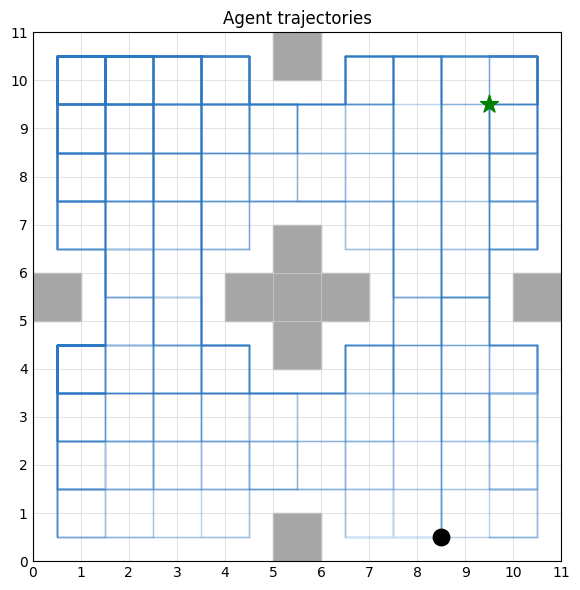

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def plot_trajectory_map(env, trajectory_history, goal_position=None, title="Agent trajectories"):
    env_core = env.unwrapped
    grid_size = env_core.grid_size
    blocked_cells = env_core._blocked_cells

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_facecolor("white")

    # Draw walls
    for (x, y) in blocked_cells:
        ax.add_patch(
            Rectangle((x, y), 1.0, 1.0, facecolor="0.65", edgecolor="0.65", zorder=1)
        )

    # Draw trajectories at cell centres
    for traj in trajectory_history:
        if traj is None or len(traj) < 2:
            continue

        traj = np.asarray(traj, dtype=np.float32)

        xs = traj[:, 0] + 0.5
        ys = traj[:, 1] + 0.5

        ax.plot(xs, ys, color="#2a78c5", alpha=0.18, linewidth=1.0, zorder=3)

    # Draw initial state of first visible trajectory
    if len(trajectory_history) > 0 and len(trajectory_history[0]) > 0:
        start = np.asarray(trajectory_history[0][0], dtype=np.float32)
        print("Start position:", start)
        ax.scatter(start[0] + 0.5, start[1] + 0.5, s=140, c="black", zorder=5)

    # Draw goal
    if goal_position is None:
        goal_position = env.goal_position if hasattr(env, "goal_position") else None

    if goal_position is not None:
        goal = np.asarray(goal_position, dtype=np.float32)
        print("Goal position:", goal)
        ax.scatter(goal[0] + 0.5, goal[1] + 0.5, s=180, c="green", marker="*", zorder=6)

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(0, grid_size + 1, 1))
    ax.set_yticks(np.arange(0, grid_size + 1, 1))
    ax.grid(color="lightgray", linewidth=0.8, alpha=0.6)
    ax.tick_params(length=0)
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


plot_trajectory_map(env_train, trajectory_history, title="Agent trajectories", goal_position=None)

### 5a. Diagnostic: Network I/O distributions & positive/negative batch example

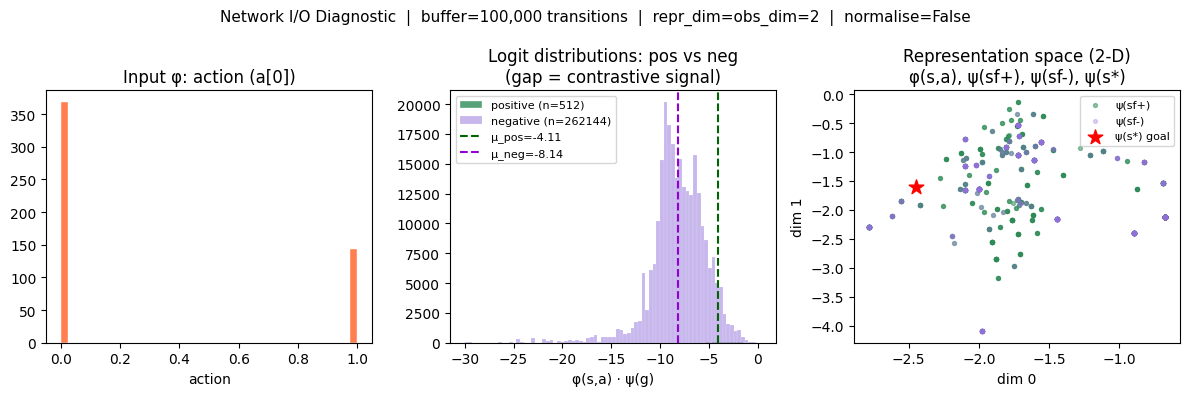


Summary statistics:
  φ(s,a) output  — mean: 0.001  std: 0.344  min: -2.130  max: 1.603
  ψ(sf+)  output  — mean: 0.007  std: 1.167  min: -4.094  max: 3.611
  ψ(sf-)  output  — mean: 0.008  std: 1.173  min: -4.094  max: 3.611
  pos logits      — mean: -4.108  std: 2.047
  neg logits      — mean: -8.138  std: 2.839
  contrastive gap (μ_pos - μ_neg): 4.030  (positive = good)


In [4]:
# ── Diagnostic: visualise network inputs, outputs, and one contrastive batch ──────
# Run this cell after training (phi_model, psi_model, replay_buffer must exist).
#
# Panel layout:
#   Row 1: distributions of raw network inputs  (state, action, goal)
#   Row 2: distributions of network outputs φ(s,a) and ψ(g)
#   Row 3: concrete single-batch example — pos logit vs neg logits distribution
#          + scatter of φ and ψ in 2-D representation space

import matplotlib.pyplot as plt
import numpy as np
import torch

_DIAG_B = 512   # batch size used for diagnostics
phi_model.eval()
psi_model.eval()

with torch.no_grad():
    # ── Sample a batch with positive future goals ─────────────────────────
    dbatch   = replay_buffer.sample_positive_future_goal_batch(_DIAG_B)
    d_obs    = dbatch["obs"]      # (B, 2)  [position, velocity]
    d_act    = dbatch["actions"]
    d_act_onehot = onehot_encode_action(d_act, num_actions=4)  # (B, 1)  action
    d_goals  = dbatch["future_state"]    # (B, 2)  positive future state sf+
    d_neg    = replay_buffer.sample_negative_future_goals(_DIAG_B)  # (B, 2) negatives

    # ── Network outputs ───────────────────────────────────────────────────
    d_phi    = phi_model(torch.cat([d_obs, d_act_onehot], dim=-1))  # (B, 2)
    d_psi_p  = psi_model(d_goals)    # (B, 2)  positive goal repr
    d_psi_n  = psi_model(d_neg)      # (B, 2)  negative goal repr

    # ── Logit distributions ───────────────────────────────────────────────
    pos_logits = (d_phi * d_psi_p).sum(dim=-1).cpu().numpy()      # (B,) diagonal
    neg_logits = (d_phi @ d_psi_n.T).cpu().numpy().flatten()      # (B*B,) all cross

    d_obs_np   = d_obs.cpu().numpy()
    d_act_np   = d_act_onehot.cpu().numpy()
    d_goals_np = d_goals.cpu().numpy()
    d_neg_np   = d_neg.cpu().numpy()
    d_phi_np   = d_phi.cpu().numpy()
    d_psi_p_np = d_psi_p.cpu().numpy()
    d_psi_n_np = d_psi_n.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))



axes[0].hist(d_act_np[:, 0], bins=40, color='coral', edgecolor='white', linewidth=0.3)
axes[0].set_title('Input φ: action (a[0])')
axes[0].set_xlabel('action')

# ── Row 2: logit distributions + 2-D scatter ──────────────────────────────────
axes[1].hist(pos_logits, bins=40, color='seagreen',    edgecolor='white', linewidth=0.3, label=f'positive (n={len(pos_logits)})', alpha=0.8)
axes[1].hist(neg_logits, bins=80, color='mediumpurple', edgecolor='white', linewidth=0.2, label=f'negative (n={len(neg_logits)})', alpha=0.5)
axes[1].axvline(np.mean(pos_logits), color='darkgreen',  linestyle='--', linewidth=1.5, label=f'μ_pos={np.mean(pos_logits):.2f}')
axes[1].axvline(np.mean(neg_logits), color='darkviolet', linestyle='--', linewidth=1.5, label=f'μ_neg={np.mean(neg_logits):.2f}')
axes[1].set_title('Logit distributions: pos vs neg\n(gap = contrastive signal)')
axes[1].set_xlabel('φ(s,a) · ψ(g)')
axes[1].legend(fontsize=8)

# 2-D scatter of φ and ψ in representation space
sc_phi = axes[2].scatter(d_psi_p_np[:, 0], d_psi_p_np[:, 1], c='seagreen',      s=8, alpha=0.5, label='ψ(sf+)')
sc_psn = axes[2].scatter(d_psi_n_np[:, 0], d_psi_n_np[:, 1], c='mediumpurple',  s=8, alpha=0.3, label='ψ(sf-)')
# Mark s* goal
with torch.no_grad():
    psi_star_np = psi_model(s_star.unsqueeze(0)).cpu().numpy()
axes[2].scatter(psi_star_np[0, 0], psi_star_np[0, 1], c='red', s=120, marker='*', zorder=5, label='ψ(s*) goal')
axes[2].set_title('Representation space (2-D)\nφ(s,a), ψ(sf+), ψ(sf-), ψ(s*)')
axes[2].set_xlabel('dim 0')
axes[2].set_ylabel('dim 1')
axes[2].legend(fontsize=8)

plt.suptitle(
    f'Network I/O Diagnostic  |  buffer={replay_buffer.size:,} transitions  |  '
    f'repr_dim=obs_dim={obs_dim}  |  normalise={phi_model.normalise}',
    fontsize=11
)
plt.tight_layout()
plt.show()

phi_model.train()
psi_model.train()

print(f'\nSummary statistics:')
print(f'  φ(s,a) output  — mean: {d_phi_np.mean():.3f}  std: {d_phi_np.std():.3f}  min: {d_phi_np.min():.3f}  max: {d_phi_np.max():.3f}')
print(f'  ψ(sf+)  output  — mean: {d_psi_p_np.mean():.3f}  std: {d_psi_p_np.std():.3f}  min: {d_psi_p_np.min():.3f}  max: {d_psi_p_np.max():.3f}')
print(f'  ψ(sf-)  output  — mean: {d_psi_n_np.mean():.3f}  std: {d_psi_n_np.std():.3f}  min: {d_psi_n_np.min():.3f}  max: {d_psi_n_np.max():.3f}')
print(f'  pos logits      — mean: {pos_logits.mean():.3f}  std: {pos_logits.std():.3f}')
print(f'  neg logits      — mean: {neg_logits.mean():.3f}  std: {neg_logits.std():.3f}')
print(f'  contrastive gap (μ_pos - μ_neg): {pos_logits.mean() - neg_logits.mean():.3f}  (positive = good)')


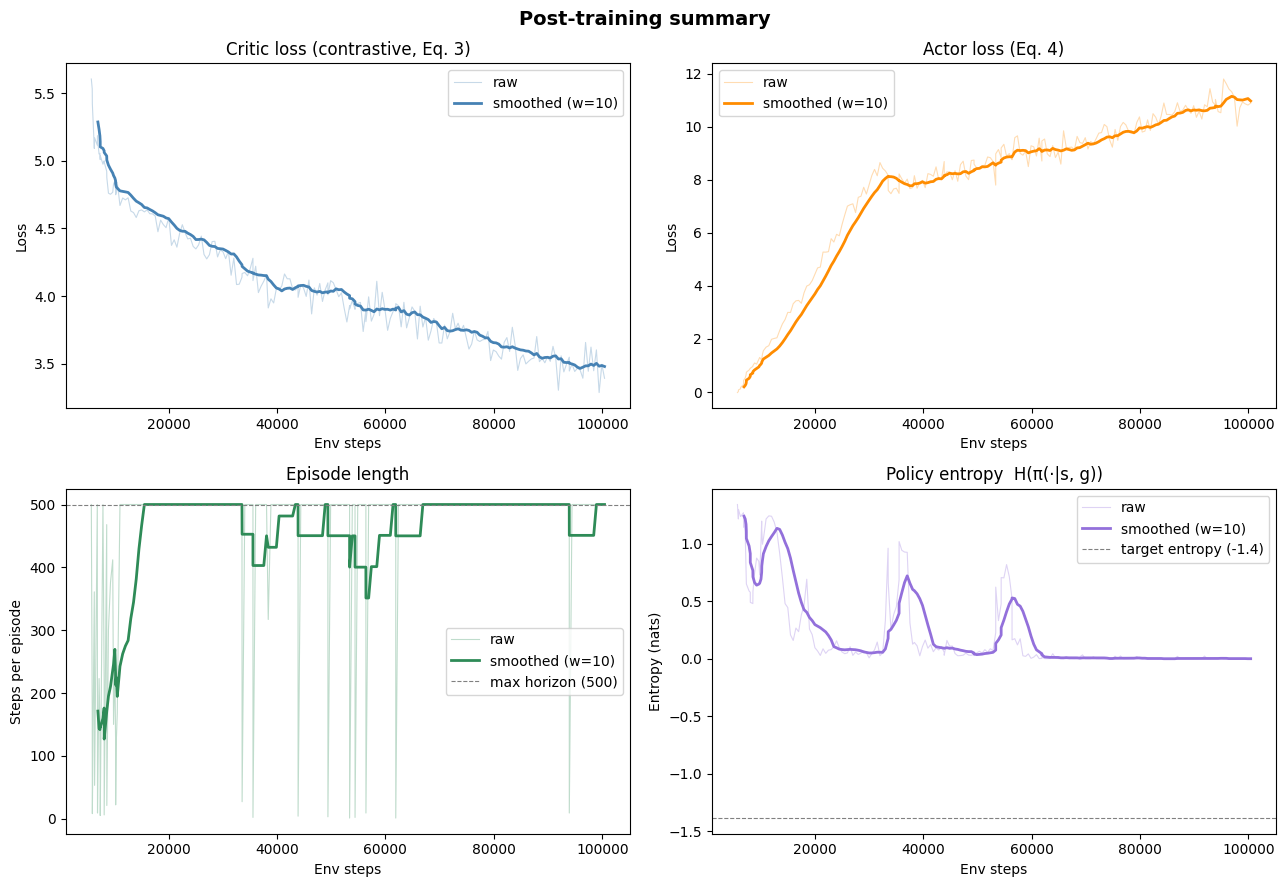

In [5]:
# ── Post-training summary: four-panel static plot ─────────────────────────────
# Smooth a 1-D list with a simple rolling window mean to reduce noise in the curves.
def smooth(values, window=10):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')

steps_full = np.asarray(env_steps_at_update)
smooth_w   = max(1, len(steps_full) // 20) if len(steps_full) > 0 else 1

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ─ Critic loss ─
ax = axes[0, 0]
ax.plot(steps_full, critic_loss_history, color='steelblue', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(critic_loss_history, smooth_w),
        color='steelblue', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Critic loss (contrastive, Eq. 3)")
ax.set_xlabel("Env steps")
ax.set_ylabel("Loss")
ax.legend()

# ─ Actor loss ─
ax = axes[0, 1]
ax.plot(steps_full, actor_loss_history, color='darkorange', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(actor_loss_history, smooth_w),
        color='darkorange', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.set_title("Actor loss (Eq. 4)")
ax.set_xlabel("Env steps")
ax.set_ylabel("Loss")
ax.legend()

# ─ Episode length ─
ax = axes[1, 0]
ax.plot(steps_full, ep_len_history, color='seagreen', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(ep_len_history, smooth_w),
        color='seagreen', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.axhline(MAX_HORIZON, color='gray', linestyle='--', linewidth=0.8, label=f'max horizon ({MAX_HORIZON})')
ax.set_title("Episode length")
ax.set_xlabel("Env steps")
ax.set_ylabel("Steps per episode")
ax.legend()
# A shorter episode that terminates (rather than truncates) means the agent reached the goal.

# ─ Policy entropy ─
ax = axes[1, 1]
ax.plot(steps_full, entropy_history, color='mediumpurple', alpha=0.3, linewidth=0.8, label='raw')
ax.plot(steps_full[smooth_w - 1:], smooth(entropy_history, smooth_w),
        color='mediumpurple', linewidth=2, label=f'smoothed (w={smooth_w})')
ax.axhline(TARGET_ENTROPY, color='gray', linestyle='--', linewidth=0.8, label=f'target entropy ({TARGET_ENTROPY:.1f})')
ax.set_title("Policy entropy  H(π(·|s, g))")
ax.set_xlabel("Env steps")
ax.set_ylabel("Entropy (nats)")
ax.legend()
# With target entropy = 0, the policy entropy should trend downward toward zero over training.

plt.suptitle("Post-training summary", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



## Q-TABLE

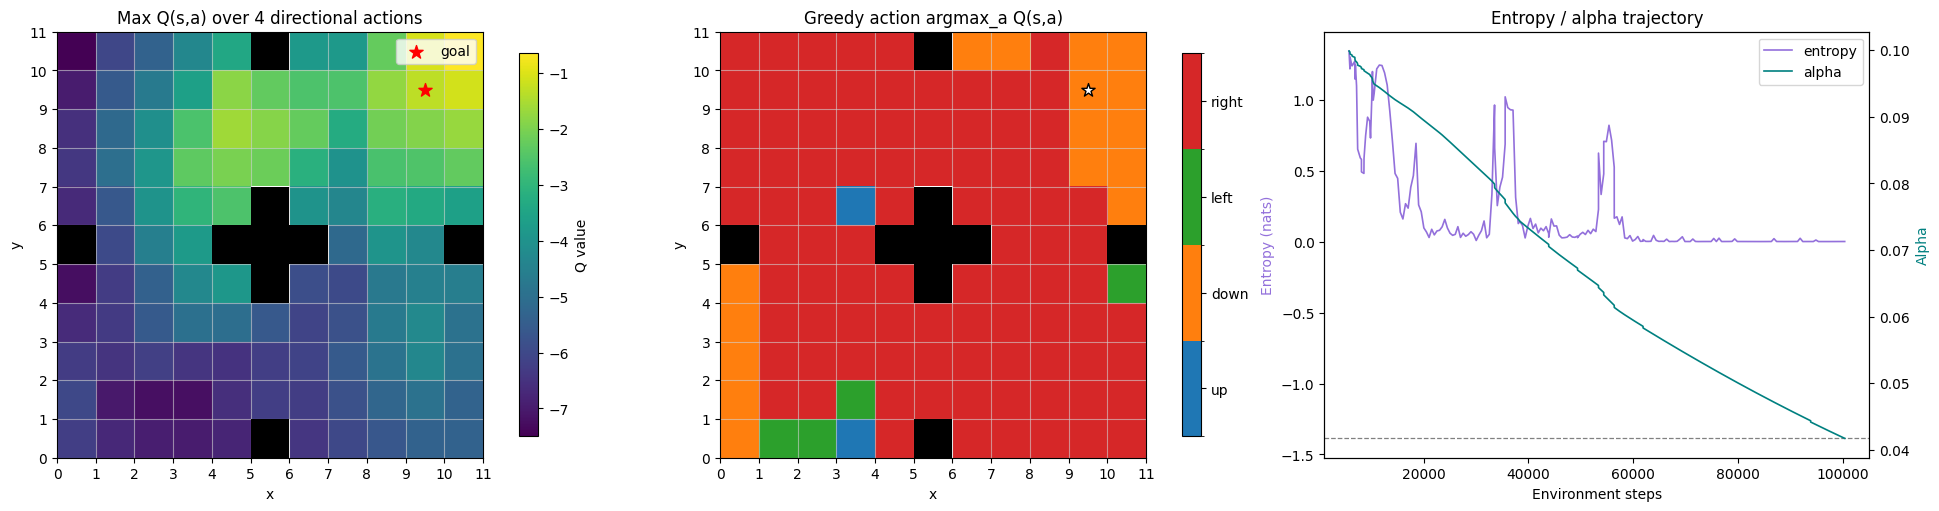

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import torch.nn.functional as F


def plot_q_diagnostics(
    env,
    s_star,
    phi_model,
    psi_model,
    device,
    entropy_history=None,
    alpha_history=None,
    env_steps_at_update=None,
    target_entropy=None,
    figsize=(20, 5),
):
    phi_model.eval()
    psi_model.eval()

    env_core = env.unwrapped
    grid_size = env_core.grid_size
    blocked_cells = env_core._blocked_cells

    num_actions = 4
    action_indices = np.arange(num_actions, dtype=np.int64)
    action_names = ["up", "down", "left", "right"]

    if not torch.is_tensor(s_star):
        s_star = torch.tensor(s_star, dtype=torch.float32, device=device)
    else:
        s_star = s_star.to(device=device, dtype=torch.float32)

    goal_embed = psi_model(s_star.unsqueeze(0)).detach()   # [1, D]

    q_best = np.full((grid_size, grid_size), np.nan, dtype=np.float32)
    best_action_idx = np.full((grid_size, grid_size), -1, dtype=np.int32)

    def overlay_walls(ax, blocked_cells, facecolor="black", alpha=1.0, edgecolor=None, lw=0.0):
        for x, y in blocked_cells:
            ax.add_patch(
                Rectangle(
                    (x, y), 1.0, 1.0,
                    facecolor=facecolor,
                    alpha=alpha,
                    edgecolor=edgecolor,
                    linewidth=lw,
                    zorder=5
                )
            )

    with torch.no_grad():
        for y in range(grid_size):
            xs = np.arange(grid_size, dtype=np.float32)
            ys = np.full_like(xs, y, dtype=np.float32)
            states_np = np.stack([xs, ys], axis=1)                      # [grid_size, 2]
            states = torch.tensor(states_np, dtype=torch.float32, device=device)

            q_per_action = []

            for a_idx in action_indices:
                a_batch = torch.full(
                    (states.shape[0],),
                    fill_value=int(a_idx),
                    dtype=torch.long,
                    device=device
                )

                a_onehot = F.one_hot(a_batch, num_classes=num_actions).float()
                phi_sa = phi_model(torch.cat([states, a_onehot], dim=-1))
                q_sa = (phi_sa * goal_embed.expand(states.shape[0], -1)).sum(dim=-1)
                q_per_action.append(q_sa.cpu().numpy())

            q_per_action = np.stack(q_per_action, axis=0)               # [4, grid_size]
            best_idx = np.argmax(q_per_action, axis=0)

            for x in range(grid_size):
                if (x, y) in blocked_cells:
                    continue
                q_best[y, x] = q_per_action[best_idx[x], x]
                best_action_idx[y, x] = best_idx[x]

    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
    extent = [0, grid_size, 0, grid_size]

    # --- Panel 1: max Q
    im0 = axes[0].imshow(
        q_best,
        origin="lower",
        aspect="equal",
        extent=extent,
        cmap="viridis",
        interpolation="nearest"
    )
    overlay_walls(axes[0], blocked_cells, facecolor="black", alpha=1.0)

    axes[0].scatter(
        float(s_star[0].item()) + 0.5,
        float(s_star[1].item()) + 0.5,
        c="red", s=100, marker="*", zorder=6, label="goal"
    )

    axes[0].set_title("Max Q(s,a) over 4 directional actions")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_xlim(0, grid_size)
    axes[0].set_ylim(0, grid_size)
    axes[0].set_xticks(np.arange(0, grid_size + 1, 1))
    axes[0].set_yticks(np.arange(0, grid_size + 1, 1))
    axes[0].grid(color="lightgray", linewidth=0.8, alpha=0.6)
    axes[0].legend(loc="upper right")
    fig.colorbar(im0, ax=axes[0], shrink=0.9, label="Q value")

    # --- Panel 2: greedy action
    action_cmap = ListedColormap(["tab:blue", "tab:orange", "tab:green", "tab:red"])
    norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), action_cmap.N)

    masked_actions = np.ma.masked_where(best_action_idx < 0, best_action_idx)

    im1 = axes[1].imshow(
        masked_actions,
        origin="lower",
        aspect="equal",
        extent=extent,
        cmap=action_cmap,
        norm=norm,
        interpolation="nearest"
    )
    overlay_walls(axes[1], blocked_cells, facecolor="black", alpha=1.0)

    axes[1].scatter(
        float(s_star[0].item()) + 0.5,
        float(s_star[1].item()) + 0.5,
        c="white", s=100, marker="*", edgecolors="black", zorder=6
    )

    axes[1].set_title("Greedy action argmax_a Q(s,a)")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].set_xlim(0, grid_size)
    axes[1].set_ylim(0, grid_size)
    axes[1].set_xticks(np.arange(0, grid_size + 1, 1))
    axes[1].set_yticks(np.arange(0, grid_size + 1, 1))
    axes[1].grid(color="lightgray", linewidth=0.8, alpha=0.6)

    cbar = fig.colorbar(im1, ax=axes[1], shrink=0.9, ticks=[0, 1, 2, 3])
    cbar.ax.set_yticklabels(action_names)

    # --- Panel 3: entropy / alpha
    has_histories = (
        entropy_history is not None and
        alpha_history is not None and
        env_steps_at_update is not None and
        len(entropy_history) > 0 and
        len(alpha_history) > 0
    )

    if has_histories:
        steps = np.array(env_steps_at_update, dtype=np.float32)
        axes[2].plot(steps, entropy_history, color="mediumpurple", linewidth=1.2, label="entropy")
        ax2 = axes[2].twinx()
        ax2.plot(steps, alpha_history, color="teal", linewidth=1.2, label="alpha")

        if target_entropy is not None:
            axes[2].axhline(target_entropy, color="gray", linestyle="--", linewidth=0.9)

        axes[2].set_title("Entropy / alpha trajectory")
        axes[2].set_xlabel("Environment steps")
        axes[2].set_ylabel("Entropy (nats)", color="mediumpurple")
        ax2.set_ylabel("Alpha", color="teal")

        h1, l1 = axes[2].get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        axes[2].legend(h1 + h2, l1 + l2, loc="upper right")
    else:
        axes[2].text(0.5, 0.5, "No alpha/entropy history found", ha="center", va="center")
        axes[2].set_axis_off()

    plt.show()


plot_q_diagnostics(env=env_train, s_star=s_star, phi_model=phi_model, psi_model=psi_model, device=DEVICE,  entropy_history=entropy_history, alpha_history=alpha_history,
    env_steps_at_update=env_steps_at_update, target_entropy=TARGET_ENTROPY)

## Transfer Evaluation


--- Transfer to goal (9, 1) (zero-shot) ---


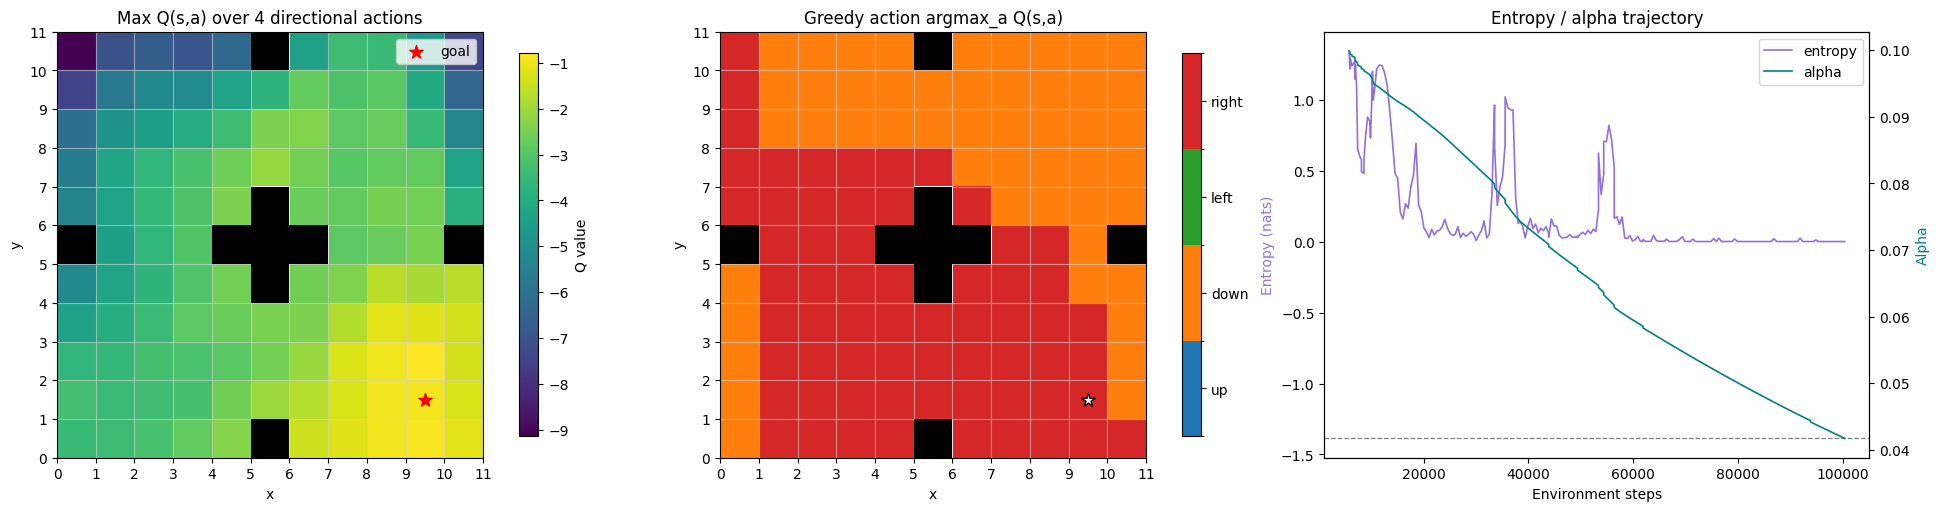

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


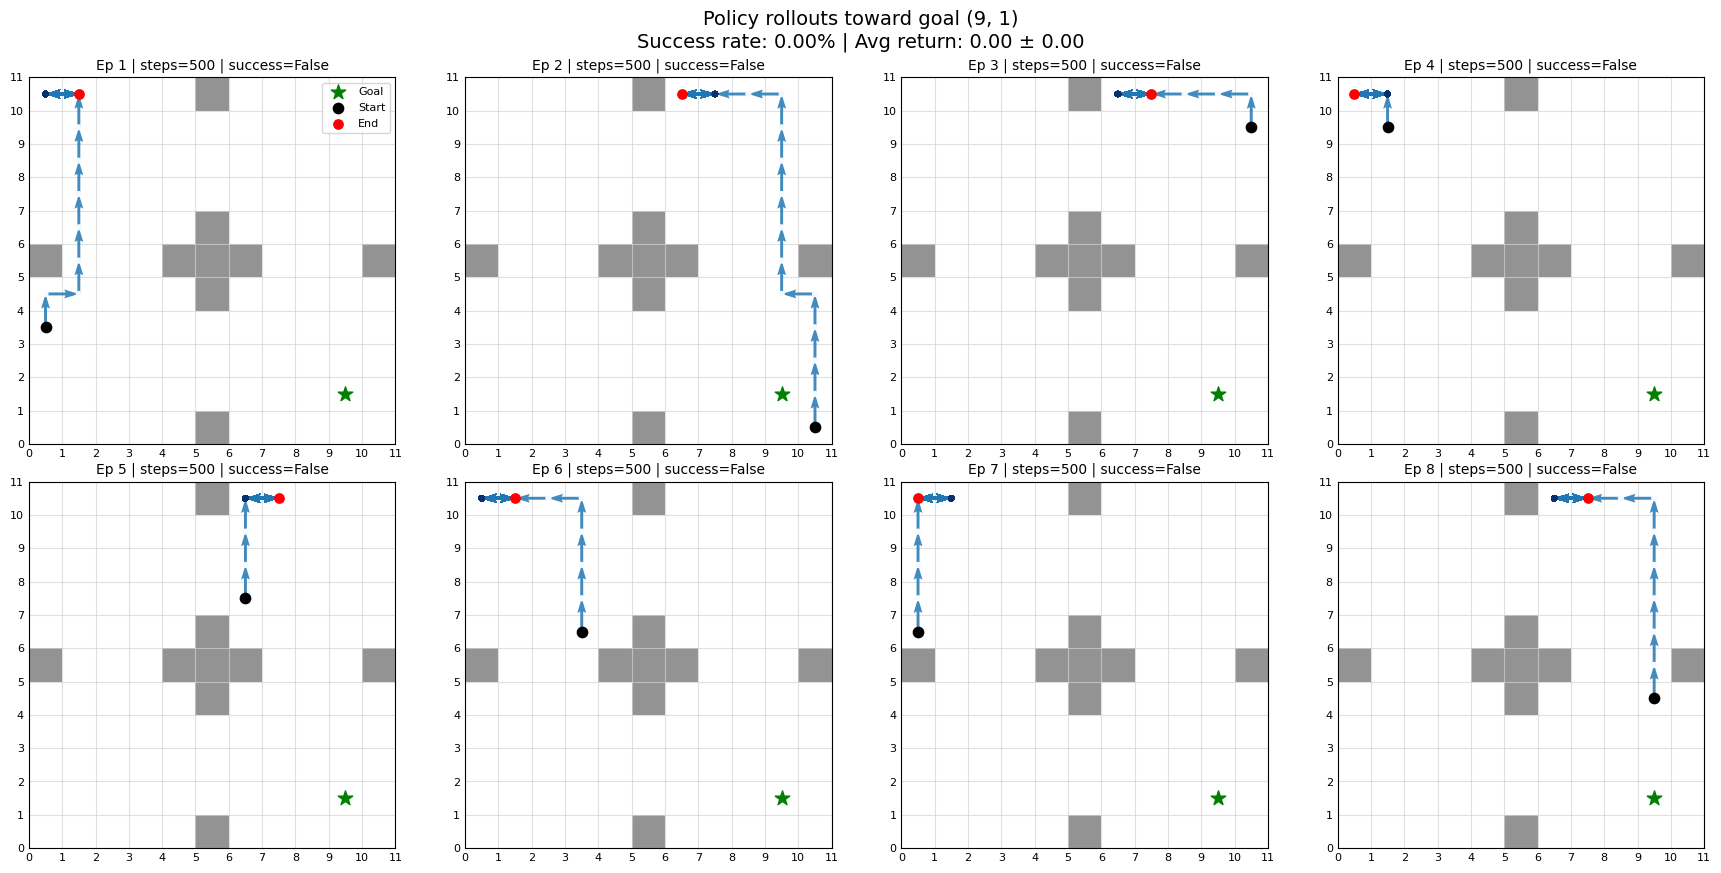


--- Transfer to goal (1, 9) (zero-shot) ---


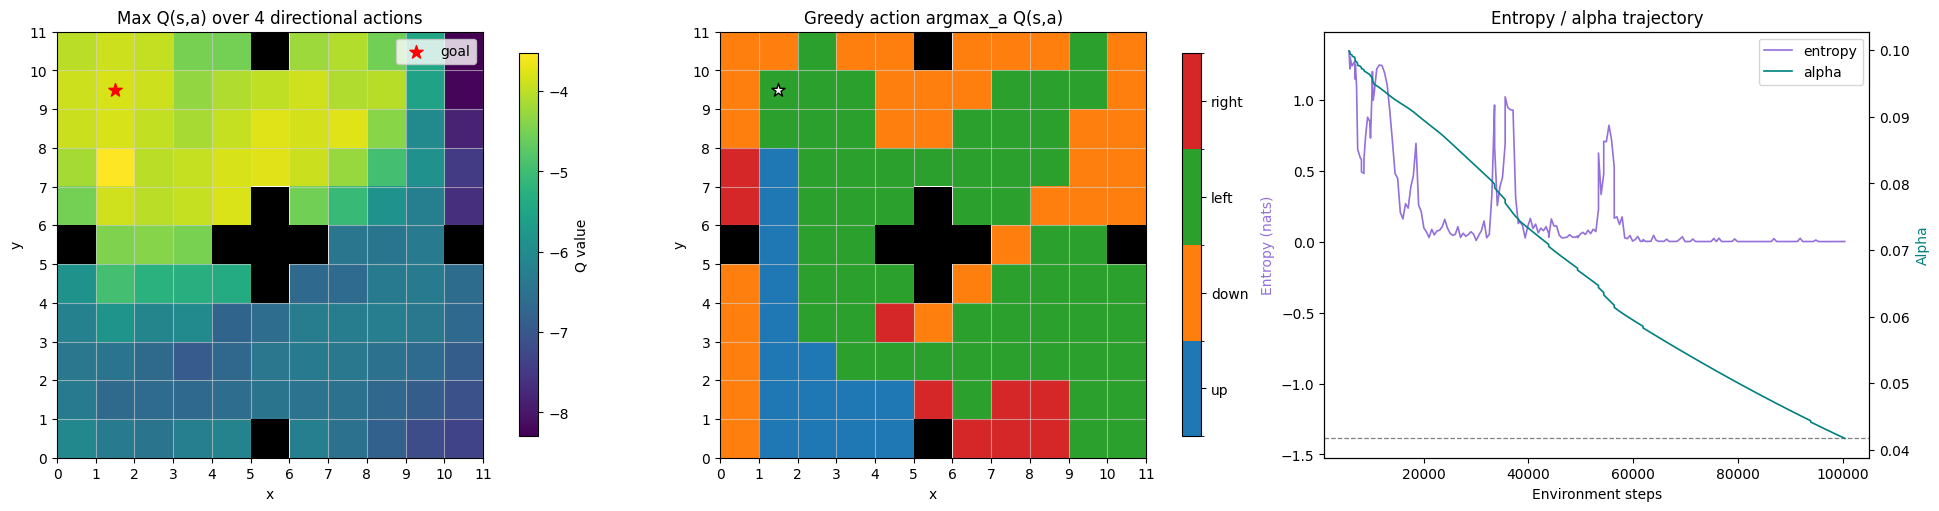

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


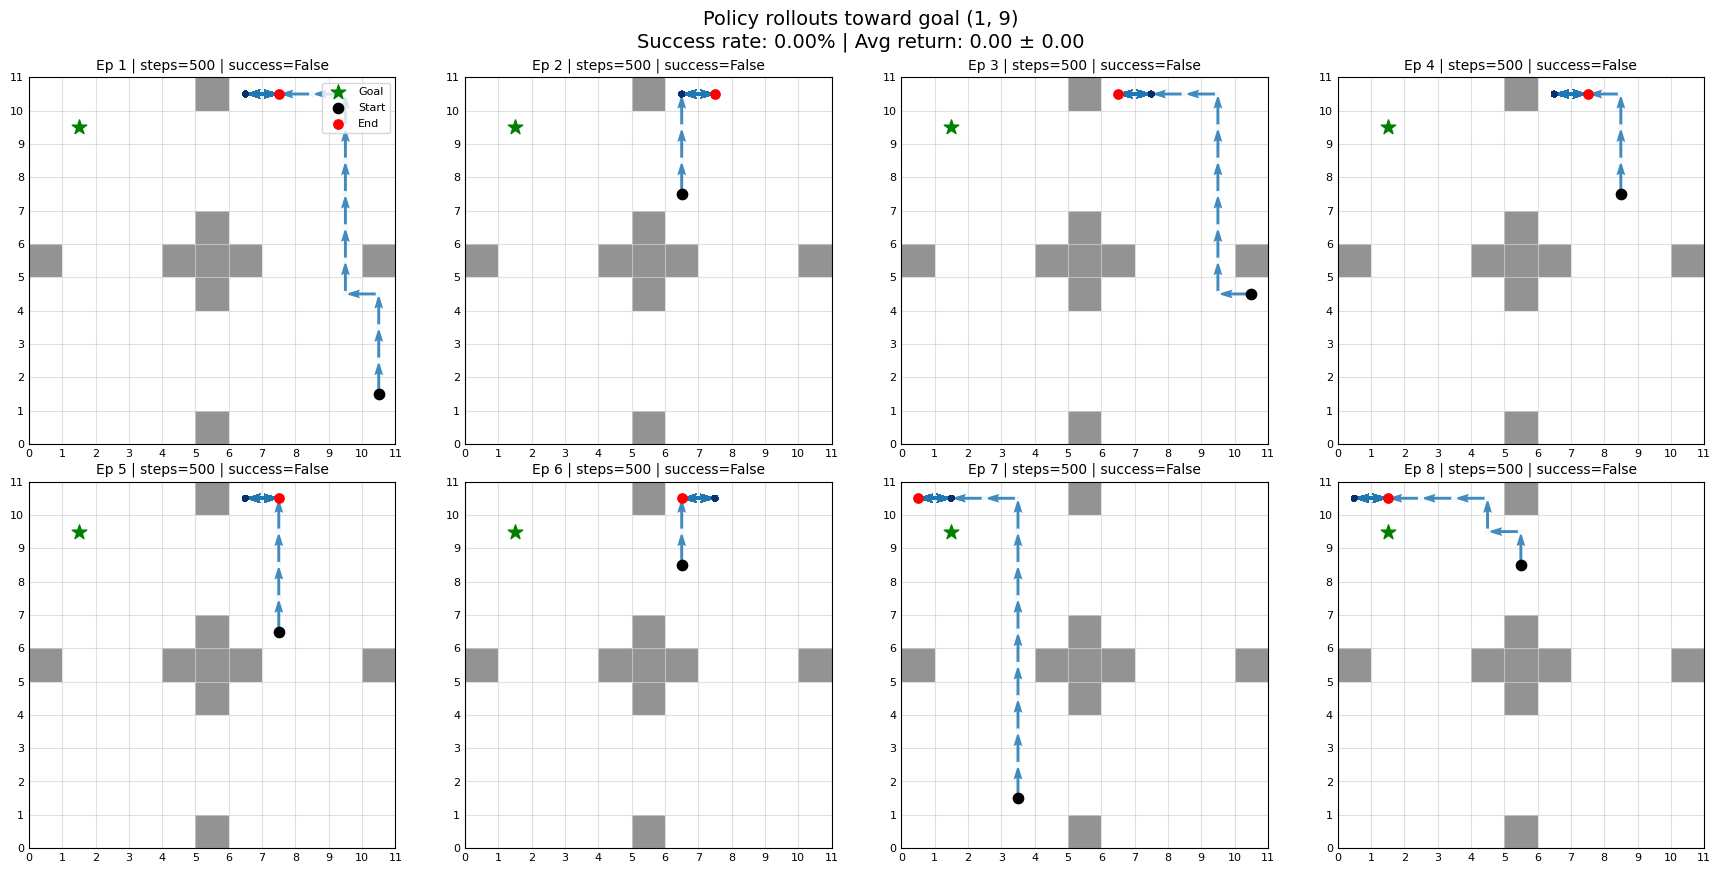

Transfer evaluation complete.


In [7]:
# ============================================================
# SGCRL transfer evaluation (FB-style, same transfer goals)
# ============================================================

phi_model.eval();  psi_model.eval();  actor.eval()

for transfer_goal in [(9, 1), (1, 9)]:

    # Build transfer environment
    base_tr = FourRoomsGridWorld(room_size=5, max_episode_steps=MAX_HORIZON)
    env_tr  = FourRoomsGoalWrapper(
        base_tr,
        goal_position=transfer_goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=SLIP_PROB,
    )

    # Compute transfer goal embedding psi(g*)
    goal_tr_t = torch.tensor(
        list(transfer_goal), dtype=torch.float32, device=DEVICE
    ).unsqueeze(0)  # [1, 2]

    with torch.no_grad():
        psi_tr = psi_model(goal_tr_t)  # [1, d]

    # Representation-score function for the transfer goal
    def sgcrl_value_fn_tr(obs_batch: np.ndarray) -> np.ndarray:
        """
        score(s, a; g*) = phi(s,a)^T psi(g*) for all actions.
        This is a representation-score diagnostic, not the actor logits.
        """
        obs_t = torch.tensor(
            np.asarray(obs_batch), dtype=torch.float32, device=DEVICE
        )
        N = obs_t.shape[0]

        with torch.no_grad():
            psi_goal = psi_tr.expand(N, -1)  # [N, d]
            q_mat = []

            for a in range(num_actions):
                a_t = torch.full((N,), a, dtype=torch.long, device=DEVICE)
                a_oh = onehot_encode_action(a_t, num_actions=num_actions)   # [N, 4]
                phi_sa = phi_model(torch.cat([obs_t, a_oh], dim=-1))        # [N, d]
                q_a = (phi_sa * psi_goal).sum(dim=-1)                       # [N]
                q_mat.append(q_a)

            q_mat = torch.stack(q_mat, dim=1)  # [N, num_actions]

        return q_mat.cpu().numpy()

    def sgcrl_greedy_tr(obs_np: np.ndarray) -> int:
        """
        Greedy actor policy for transfer goal:
            a* = argmax_a actor(s, g*)
        with valid-action masking.
        """
        obs_t = torch.tensor(
            np.asarray(obs_np), dtype=torch.float32, device=DEVICE
        ).unsqueeze(0)  # [1, 2]

        mask_np = env_tr.unwrapped.valid_action_mask(obs_np)  # [4]
        mask_t = torch.tensor(mask_np, dtype=torch.bool, device=DEVICE).unsqueeze(0)

        with torch.no_grad():
            logits = actor.forward(obs_t, goal_tr_t)          # [1, 4]
            logits = logits.masked_fill(~mask_t, -1e9)
            action = logits.argmax(dim=-1)

        return int(action.item())

    # Q/score heatmap for transfer goal
    print(f"\n--- Transfer to goal {transfer_goal} (zero-shot) ---")

    # If your imported helper accepts a generic value_fn like in the FB notebook:
    try:
        plot_q_diagnostics(
            env          = env_tr,
            value_fn     = sgcrl_value_fn_tr,
            is_discrete  = True,
            num_actions  = 4,
            action_names = ["Up", "Down", "Left", "Right"],
            goal_pos     = transfer_goal,
            eval_returns = None,
            figsize      = (20, 5),
        )
    except TypeError:
        # Fall back to the SGCRL notebook's existing helper signature
        plot_q_diagnostics(
            env                 = env_tr,
            s_star              = np.array(transfer_goal, dtype=np.float32),
            phi_model           = phi_model,
            psi_model           = psi_model,
            device              = DEVICE,
            entropy_history     = entropy_history,
            alpha_history       = alpha_history,
            env_steps_at_update = env_steps_at_update,
            target_entropy      = TARGET_ENTROPY,
            figsize             = (20, 5),
        )

    # Policy rollouts for transfer goal
    plot_policy_rollouts(
        env             = env_tr,
        policy_fn       = sgcrl_greedy_tr,
        goal_pos        = transfer_goal,
        eval_episodes   = 8,
        n_cols          = 4,
        is_discrete     = True,
        step_point_size = 12,
    )

    env_tr.close()

phi_model.train();  psi_model.train();  actor.train()
print("Transfer evaluation complete.")